# GRU: a compact gated recurrent unit

**Learning objective:** Understand the GRU's update/reset gates and compare its parameter count with an LSTM.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:13:41.689920: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974821.705078    3074 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974821.709387    3074 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:13:43.404712: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
input_dim=5; units=8
rnn=tf.keras.layers.SimpleRNN(units); lstm=tf.keras.layers.LSTM(units); gru=tf.keras.layers.GRU(units)
dummy=tf.zeros((2,12,input_dim)); _=rnn(dummy); _=lstm(dummy); _=gru(dummy)
display(pd.DataFrame({"layer":["SimpleRNN","LSTM","GRU"],"parameters":[rnn.count_params(),lstm.count_params(),gru.count_params()]}))


,layer,parameters
0,SimpleRNN,112
1,LSTM,448
2,GRU,360


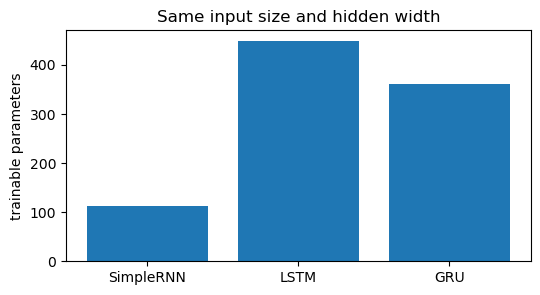

In [3]:
labels=["SimpleRNN","LSTM","GRU"]; vals=[rnn.count_params(),lstm.count_params(),gru.count_params()]
plt.figure(figsize=(6,3)); plt.bar(labels,vals); plt.ylabel("trainable parameters"); plt.title("Same input size and hidden width"); plt.show()


GRU merges some of the LSTM's gating machinery and has no separate cell state. Neither architecture is universally superior: validation performance, latency and memory determine the choice.
